In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from peak_extraction.extract_peaks import baseline_peak_fit, single_t_distribution, plaxco_gauss_fit, baseline_peak_fit
from matplotlib.colors import Normalize
from scipy.stats import t
from peak_extraction.extract_peaks import (baseline_peak_fit, plaxco_gauss_fit, poly_linear_fit,
                                           i_extract_ewd, set_peak_prominence, set_huber_cutoff)

%load_ext autoreload
%autoreload 2

In [2]:
def compute_error_stats(df: pd.DataFrame, methods, bad_threshold: float = 0.27):

    all_method_frames = []

    required_cols = {"baseline", "psnr_db", "replicate", "amp"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    for method in methods:
        peak_col = f"{method}_peak"
        if peak_col not in df.columns:
            raise KeyError(f"Column '{peak_col}' not found in DataFrame")

        temp = df.copy()
        temp["error"] = temp[peak_col].astype(float) - temp["amp"].astype(float)

        err_stats = (
            temp.groupby(["baseline", "psnr_db", "amp"])["error"]
                .agg(
                    mean_err="mean",
                    std_err="std",
                    n="count"
                )
        )

        # standard error
        err_stats["std_err"] = err_stats["std_err"]

        bad = err_stats["std_err"] > bad_threshold
        err_stats.loc[bad, ["mean_err", "std_err"]] = np.nan

        err_stats = (
            err_stats.reset_index()
                     .assign(method=method)
                     .set_index(["method", "psnr_db", "baseline", "amp"])
                     .sort_index()
        )

        all_method_frames.append(err_stats[["mean_err", "std_err"]])

    if not all_method_frames:
        return pd.DataFrame()

    stats = pd.concat(all_method_frames)

    mean = stats["mean_err"].unstack(["baseline", "amp"])
    sem  = stats["std_err"].unstack(["baseline", "amp"])

    out = pd.concat({"mean_err": mean, "std_err": sem}, axis=1).sort_index(axis=1)
    return out

def compute_peak_stats(
    df: pd.DataFrame,
    methods,
    bad_threshold: float = 0.27
):
    all_method_frames = []

    required_cols = {"replicate", "amp"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    for method in methods:
        peak_col = f"{method}_peak"
        if peak_col not in df.columns:
            raise KeyError(f"Column '{peak_col}' not found in DataFrame")

        temp = df.copy()
        temp["peak_val"] = temp[peak_col].astype(float)

        peak_stats = (
            temp.groupby(["amp"])["peak_val"]
                .agg(
                    mean_peak="mean",
                    std_peak="std",
                    n="count"
                )
        )

        # standard error
        peak_stats["std_peak"] = peak_stats["std_peak"]

        bad = peak_stats["std_peak"] > bad_threshold
        peak_stats.loc[bad, ["mean_peak", "std_peak"]] = np.nan

        peak_stats = (
            peak_stats.reset_index()
                      .assign(method=method)
                      .set_index(["method", "amp"])
                      .sort_index()
        )

        all_method_frames.append(peak_stats[["mean_peak", "std_peak"]])

    if not all_method_frames:
        return pd.DataFrame()

    stats = pd.concat(all_method_frames)

    mean = stats["mean_peak"].unstack(["amp"])
    sem  = stats["std_peak"].unstack(["amp"])

    out = pd.concat({"mean_peak": mean, "std_peak": sem}, axis=1).sort_index(axis=1)
    return out


In [10]:
path = 'simulation/simulation_data/huber_panel.feather'
df = pd.read_feather(path)
methods = ['aswift_huber0', 'aswift_huber1', 'aswift_huber2', 'aswift_huber3']
stats_df = compute_error_stats(df, methods)
save_path ='simulation/simulation_data/paper_data/huber_summary.feather'
stats_df.to_feather(save_path)
print(stats_df)


                         mean_err                                     std_err  \
baseline              exponential    linear multigauss polynomial exponential   
amp                           1.0       1.0        1.0        1.0         1.0   
method        psnr_db                                                           
aswift_huber0 15.0      -0.145903 -0.128963  -0.156229  -0.159558    0.028749   
              20.0      -0.112205 -0.102769  -0.123021  -0.118797    0.038732   
              25.0      -0.023593 -0.015887  -0.031740  -0.026399    0.028871   
              30.0      -0.030815 -0.016615  -0.038892  -0.035335    0.015363   
              35.0      -0.027957 -0.019201  -0.034522  -0.031469    0.011213   
              40.0      -0.016850 -0.008942  -0.023414  -0.020461    0.012712   
              45.0      -0.011254 -0.000962  -0.017715  -0.014650    0.012879   
              50.0      -0.010819 -0.001322  -0.016367  -0.013730    0.013937   
              55.0      -0.0

In [3]:
path = 'simulation/simulation_data/sim_binding_curve_mg_ewd.feather'
df = pd.read_feather(path)
methods = ["aswift", "polynomial", "multigauss", "ewd"]
stats_df = compute_peak_stats(df, methods)
save_path = 'simulation/simulation_data/binding_summary_2.feather'
stats_df.to_feather(save_path)
print(stats_df)

           mean_peak                                                    \
amp            0.505     0.511     0.522     0.545     0.589     0.659   
method                                                                   
aswift      0.504089  0.517149  0.523538  0.544113  0.591160  0.662294   
ewd         0.467321  0.479484  0.484706  0.509319  0.545006  0.611621   
multigauss  0.529331  0.541487  0.548792  0.573736  0.617735  0.686244   
polynomial  0.459429  0.469474  0.479534  0.501172  0.540646  0.600016   

                                                    ...  std_peak            \
amp            0.750     0.841     0.911     0.955  ...     1.045     1.089   
method                                              ...                       
aswift      0.749940  0.849662  0.916255  0.957288  ...  0.008068  0.008586   
ewd         0.679025  0.778665  0.851501  0.886253  ...  0.051377  0.042933   
multigauss  0.779851  0.882203  0.958433  1.000635  ...  0.053649  0.055591   
polynom

In [4]:
path = 'simulation/simulation_data/paper_data/panel_random_bl.feather'
df = pd.read_feather(path)
# dropping the sigmoid baseline to avoid biasing multi-gauss
df = df[df["baseline"] != "sigmoid"].copy()
print(df.shape)
print(df.head(n=1))

(10800, 17)
  baseline  class  psnr_db  width  amp  location  replicate   bl_true  \
0   linear      0     15.0    0.2  1.0     -0.25          0  0.291425   

                                              signal  aswift_peak  aswift_bl  \
0  [0.18312687764962174, 0.243315302646671, 0.308...      1.02835   0.238192   

   polynomial_peak  polynomial_bl  multigauss_peak  multigauss_bl  ewd_peak  \
0         0.860944       0.206131         1.078573       0.268749  0.965959   

     ewd_bl  
0  0.153247  


In [5]:
methods = ["aswift", "polynomial", "multigauss", "ewd"]
stats_df = compute_error_stats(df, methods)
save_path = 'simulation/simulation_data/paper_data/panel.feather'
stats_df.to_feather(save_path)

print(stats_df)

                      mean_err                                     std_err  \
baseline           exponential    linear multigauss polynomial exponential   
amp                        1.0       1.0        1.0        1.0         1.0   
method     psnr_db                                                           
aswift     15.0       0.018301  0.050436   0.010769   0.009541    0.053795   
           20.0       0.002323  0.020877  -0.004561  -0.001443    0.034000   
           25.0      -0.014800 -0.000566  -0.020745  -0.018883    0.023007   
           30.0      -0.005928  0.002545  -0.014441  -0.010190    0.020548   
           35.0      -0.004960  0.002736  -0.011541  -0.008116    0.018774   
           40.0      -0.006514  0.004836  -0.013051  -0.010403    0.015597   
           45.0      -0.007905  0.001853  -0.013789  -0.011179    0.015651   
           50.0      -0.009309  0.000267  -0.015672  -0.012814    0.014147   
           55.0      -0.009424 -0.000983  -0.015609  -0.013030  

In [94]:
def load_sim_results(path):
    df = pd.read_feather(path)
    with np.errstate(divide='ignore', invalid='ignore'):
        df["trds_accuracy"] = np.log10((df["trds_peak"] - df["trds_bl"]) / df["amp"]).abs()
        df["poly_accuracy"] = np.log10((df["polynomial_peak"] - df["polynomial_bl"]) / df["amp"]).abs()
        df["gauss_accuracy"] = np.log10((df["multigauss_peak"] - df["multigauss_bl"]) / df["amp"]).abs()

    df_sum_all = (
        df.groupby(["psnr_db", "width", "amp"])
          .agg(trds_mean=("trds_accuracy", "mean"),
               poly_mean=("poly_accuracy", "mean"),
               gauss_mean=("gauss_accuracy", "mean"),
               n=("trds_accuracy", "size"))
          .reset_index()
    )

    df_sum_by_loc = (
        df.groupby(["psnr_db", "width", "amp", "location"])
          .agg(trds_mean=("trds_accuracy", "mean"),
               poly_mean=("poly_accuracy", "mean"),
               gauss_mean=("gauss_accuracy", "mean"),
               n=("trds_accuracy", "size"))
          .reset_index()
    )

    return df, df_sum_all, df_sum_by_loc


def variable_psnr_heatmap(df_sum, variable, amp_sel=1.0, location_sel=None, title_suffix="", fontsize=14, xtick_step=10):
    if location_sel is not None:
        df_sum = df_sum[df_sum["location"].eq(location_sel)]

    def grid(df, metric):
        g = (df[df["amp"] == amp_sel]
             .pivot_table(index=variable, columns="psnr_db", values=metric, aggfunc="mean")
             .sort_index(axis=0).sort_index(axis=1))
        return g

    def _xtick_positions_and_labels(G_columns, step):
        vals = pd.to_numeric(pd.Index(G_columns), errors='coerce').to_numpy(dtype=float)
        # Fallback: if any non-numeric, return all columns (won't apply 10-step nicely)
        if not np.isfinite(vals).all():
            idx = np.arange(len(G_columns))
            labels = list(G_columns)
            return idx, labels
        base = np.floor(vals.min() / step) * step
        idx = [i for i, v in enumerate(vals) if np.isfinite(v) and np.isclose((v - base) % step, 0.0)]
        labels = [int(vals[i]) if float(vals[i]).is_integer() else vals[i] for i in idx]
        return idx, labels

    def show(ax, G, title, norm):
        im = ax.imshow(G.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm", norm=norm)
        # Y ticks (all rows)
        ax.set_yticks(range(G.shape[0]))
        ax.set_yticklabels(G.index, fontsize=fontsize)
        # X ticks (every 10 dB)
        xt_idx, xt_labels = _xtick_positions_and_labels(G.columns, xtick_step)
        ax.set_xticks(xt_idx)
        ax.set_xticklabels(xt_labels, fontsize=fontsize)
        ax.set_title(title, fontsize=fontsize+2)
        ax.set_xlabel("psnr (dB)", fontsize=fontsize)
        return im

    G_trds  = grid(df_sum, "trds_mean")
    G_poly  = grid(df_sum, "poly_mean")
    G_gauss = grid(df_sum, "gauss_mean")

    all_vals = np.concatenate([G_trds.values.ravel(), G_poly.values.ravel(), G_gauss.values.ravel()])
    all_vals = all_vals[~np.isnan(all_vals)]
    vmin = float(np.min(all_vals)) if all_vals.size else 0.0
    vmax = float(np.max(all_vals)) if all_vals.size else 1.0
    norm = Normalize(vmin=vmin, vmax=0.5)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=True)

    im1 = show(axes[0], G_trds,  f"ASWiFT {title_suffix}", norm)
    im2 = show(axes[1], G_poly,  f"Polynomial {title_suffix}", norm)
    im3 = show(axes[2], G_gauss, f"Multi-Gaussian {title_suffix}", norm)

    axes[0].set_ylabel(f"peak {variable}", fontsize=fontsize)
    for ax in axes:
        ax.tick_params(axis='both', which='both', labelsize=fontsize)

    cbar = fig.colorbar(im3, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("log error", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.show()



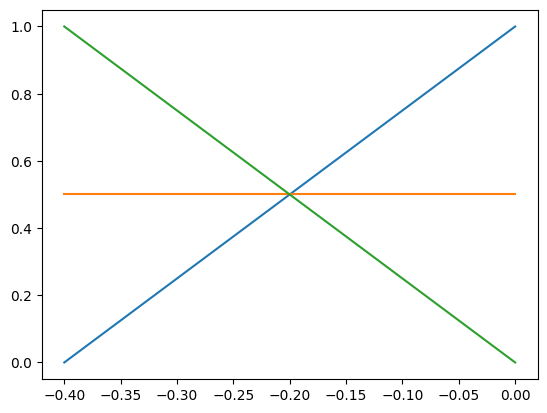

In [95]:
path = 'simulation/simulation_data/iterative_trds.feather'
df, df_sum, df_sum_loc = load_sim_results(path)
variable_psnr_heatmap(df_sum, "width")

In [96]:
loc_val = df_sum_loc["location"].dropna().unique()[4]
variable_psnr_heatmap(df_sum_loc, "width", amp_sel=1.0, location_sel=loc_val)

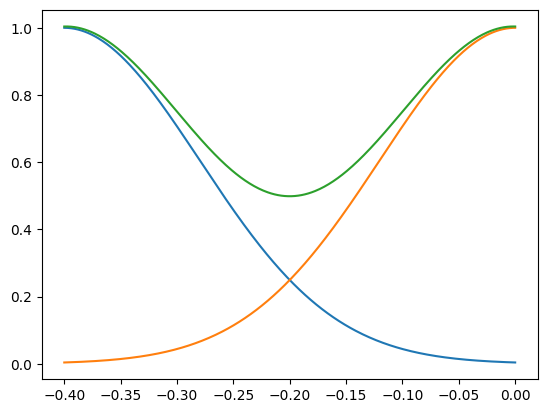

In [105]:
def accuracy_by_location(df_sum_loc, ax=None, width_lo=0.2, width_hi=0.5, psnr_lo=30):
    sub = df_sum_loc[
        df_sum_loc["width"].between(width_lo, width_hi) & (df_sum_loc["psnr_db"] >= psnr_lo)
    ].copy()

    agg = (sub.groupby("location", as_index=False)
              .agg(trds_mean=("trds_mean", "mean"),
                   poly_mean=("poly_mean", "mean"),
                   gauss_mean=("gauss_mean", "mean"),
                   trds_sem=("trds_mean", lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else np.nan),
                   poly_sem=("poly_mean", lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else np.nan),
                   gauss_sem=("gauss_mean", lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else np.nan))
          ).sort_values("location")

    x = agg["location"].to_numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(7,4))

    ax.errorbar(x, agg["trds_mean"],  yerr=agg["trds_sem"],  fmt='o-', capsize=4, color='red', label="ASWiFT")
    ax.errorbar(x, agg["poly_mean"],  yerr=agg["poly_sem"],  fmt='s--', capsize=4, color='blue', label="Polynomial")
    ax.errorbar(x, agg["gauss_mean"], yerr=agg["gauss_sem"], fmt='^-.', capsize=4, color='green', label="Multi-Gaussian")

    ax.set_xlabel("location")
    ax.set_ylabel("average log error")
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)


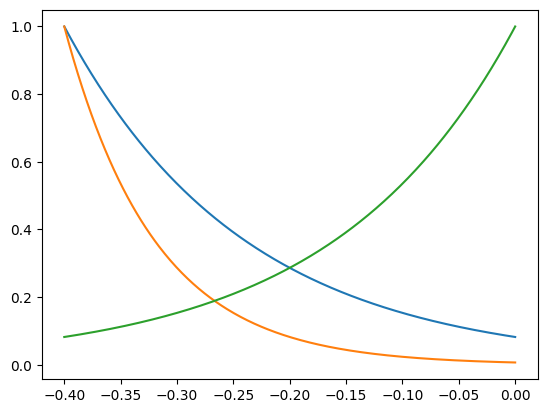

In [110]:
fig, ax = plt.subplots(figsize=(6,4))
_ = accuracy_by_location(df_sum_loc, ax=ax, width_lo=0.2, width_hi=0.5, psnr_lo=30)
plt.show()

In [2]:
n = 400
x_lower = -0.4
x_upper = 0.0

x = np.linspace(x_lower, x_upper, n)

In [38]:
def _linear_panel_shapes(x: np.ndarray, n: int = 30, seed: int=0) -> np.ndarray:
    """
    n random linear baseline shapes (n, N):

    Model:
        y(t) = b + at
    """
    x = np.asarray(x, dtype=float)
    x_lower = float(x[0])
    x_upper = float(x[-1])
    dx = x_upper - x_lower
    if dx == 0:
        raise ValueError("x_upper must be different from x_lower")

    rng = np.random.default_rng(seed)
    t = (x - x_lower) / dx  # (N,)

    a = rng.uniform(-1.0, 1.0, size=n)
    b = rng.uniform(-0.5, 0.5, size=n)

    Y = b[:, None] + a[:, None] * t[None, :]  # (n, N)
    return Y

Y = _linear_panel_shapes(x, n=10)
plt.plot(x, Y.T)
plt.show()

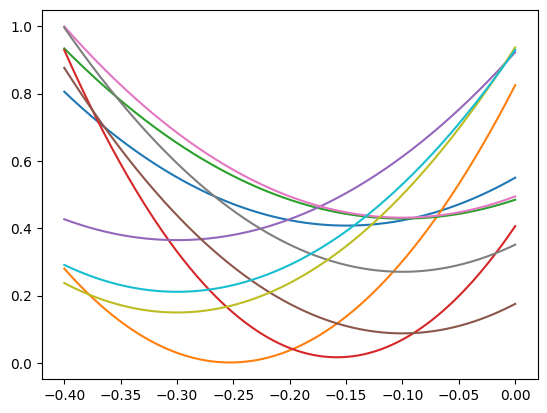

In [39]:
def _poly_panel_shapes(x: np.ndarray, n: int = 30, seed: int=0) -> np.ndarray:
    """
    n random polynomial baseline shapes (n, N):

    Model:
        y(t) = y0 + a(t - t0)^2
    """
    x = np.asarray(x, dtype=float)
    x_lower = float(x[0])
    x_upper = float(x[-1])
    dx = x_upper - x_lower
    if dx == 0:
        raise ValueError("x_upper must be different from x_lower")

    rng = np.random.default_rng(seed)
    t = (x - x_lower) / dx  # (N,)

    t0 = rng.normal(loc=0.5, scale=1.0, size=n)
    t0 = np.clip(t0, 0.25, 0.75)
    y0 = rng.uniform(0.0, 0.5, size=n)
    y_edge = rng.uniform(0.8, 1.0, size=n)

    denom = np.maximum(t0**2, (1.0 - t0)**2)
    a = (y_edge - y0) / denom
    a = np.maximum(a, 0.0)

    Y = y0[:, None] + a[:, None] * (t[None, :] - t0[:, None])**2  # (n, N)
    return Y

Y = _poly_panel_shapes(x, n=10)
plt.plot(x, Y.T)
plt.show()

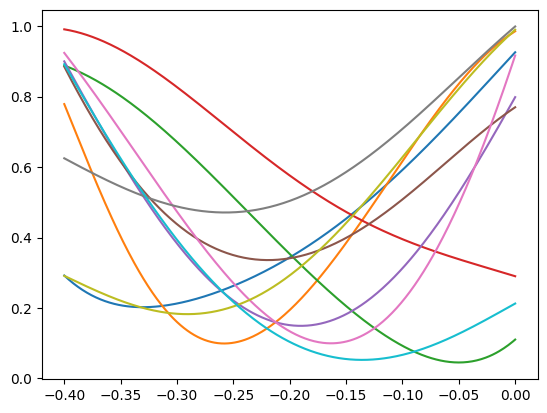

In [48]:
def _multigauss_panel_shapes(x: np.ndarray, n: int = 30, seed: int = 0) -> np.ndarray:
    """
    Sum of 2 Gaussians, both centers are outside the x-range
    """
    x = np.asarray(x, dtype=float)
    x0 = float(x[0])
    x1 = float(x[-1])
    L = x1 - x0
    if L == 0:
        raise ValueError("x_upper must be different from x_lower")

    rng = np.random.default_rng(seed)

    def gauss(x_, mu, sigma):
        return np.exp(-0.5 * ((x_ - mu) / sigma) ** 2)

    # centers placed outside by a random offset
    offL = rng.uniform(0.10, 0.60, size=n) * L
    offR = rng.uniform(0.10, 0.60, size=n) * L
    muL = x0 - offL
    muR = x1 + offR

    # widths and weights
    sigL = rng.uniform(0.20, 0.70, size=n) * L
    sigR = rng.uniform(0.20, 0.70, size=n) * L
    wL = rng.uniform(0.2, 1.0, size=n)
    wR = rng.uniform(0.2, 1.0, size=n)

    base = wL[:, None] * gauss(x[None, :], muL[:, None], sigL[:, None]) \
         + wR[:, None] * gauss(x[None, :], muR[:, None], sigR[:, None])

    # scale each row to roughly match your linear/poly magnitudes
    y_low  = rng.uniform(0.0, 0.5, size=n)
    y_high = rng.uniform(0.8, 1.0, size=n)

    bmin = base.min(axis=1)
    bmax = base.max(axis=1)
    denom = np.maximum(bmax - bmin, 1e-12)
    base01 = (base - bmin[:, None]) / denom[:, None]

    Y = y_low[:, None] + (y_high - y_low)[:, None] * base01
    return Y

Y = _multigauss_panel_shapes(x, n=10)
plt.plot(x, Y.T)
plt.show()

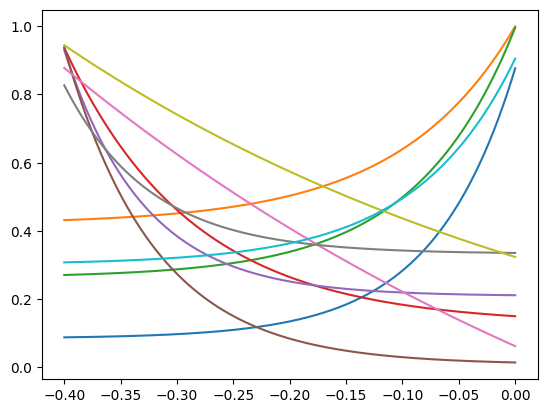

In [44]:
def _exp_panel_shapes(x: np.ndarray, n: int = 30, seed: int = 0) -> np.ndarray:
    """
    n simple exponential baseline shapes (n, N)

    decay: y = c + a * exp(-k t)
    grow:  y = c + a * exp(+k t)
    """
    x = np.asarray(x, dtype=float)
    x0 = float(x[0])
    x1 = float(x[-1])
    L = x1 - x0
    if L == 0:
        raise ValueError("x_upper must be different from x_lower")

    rng = np.random.default_rng(seed)
    t = (x - x0) / L  # (N,)

    # choose direction: -1 decay, +1 increase
    sgn = rng.choice(np.array([-1.0, 1.0]), size=n)

    # curvature strength (dimensionless)
    k = rng.uniform(0.6, 6.0, size=n)

    base = np.exp((sgn[:, None] * k[:, None]) * t[None, :])

    # scale each row to match linear/poly magnitudes
    y_low  = rng.uniform(0.0, 0.5, size=n)
    y_high = rng.uniform(0.8, 1.0, size=n)

    bmin = base.min(axis=1)
    bmax = base.max(axis=1)
    denom = np.maximum(bmax - bmin, 1e-12)
    base01 = (base - bmin[:, None]) / denom[:, None]

    Y = y_low[:, None] + (y_high - y_low)[:, None] * base01
    return Y

Y = _exp_panel_shapes(x, n=10)
plt.plot(x, Y.T)
plt.show()